In [2]:
from pathlib import Path

data_dir = Path("../data")

patients = sorted(data_dir.glob("patient*"))

print(f"Number of patients: {len(patients)}")

Number of patients: 3


In [3]:
for patient in patients[:3]:
    print(patient)
    print(list(patient.glob("*")))

..\data\Patient001
[WindowsPath('../data/Patient001/Info.cfg'), WindowsPath('../data/Patient001/MANDATORY_CITATION.md'), WindowsPath('../data/Patient001/patient001_4d.nii.gz'), WindowsPath('../data/Patient001/patient001_frame01.nii.gz'), WindowsPath('../data/Patient001/patient001_frame01_gt.nii.gz'), WindowsPath('../data/Patient001/patient001_frame12.nii.gz'), WindowsPath('../data/Patient001/patient001_frame12_gt.nii.gz')]
..\data\patient002
[WindowsPath('../data/patient002/Info.cfg'), WindowsPath('../data/patient002/MANDATORY_CITATION.md'), WindowsPath('../data/patient002/patient002_4d.nii.gz'), WindowsPath('../data/patient002/patient002_frame01.nii.gz'), WindowsPath('../data/patient002/patient002_frame01_gt.nii.gz'), WindowsPath('../data/patient002/patient002_frame12.nii.gz'), WindowsPath('../data/patient002/patient002_frame12_gt.nii.gz')]
..\data\patient003
[WindowsPath('../data/patient003/Info.cfg'), WindowsPath('../data/patient003/MANDATORY_CITATION.md'), WindowsPath('../data/pati

In [5]:
import nibabel as nib
import pandas as pd

records = []

for patient in patients:

    files = list(patient.glob("*frame*.nii.gz"))

    for file in files:

        if "_gt" in str(file):
            continue

        img = nib.load(file)

        shape = img.shape
        spacing = img.header.get_zooms()

        records.append({
            "file": file.name,
            "shape": shape,
            "spacing": spacing
        })

df = pd.DataFrame(records)

df.head()

,file,shape,spacing
0,patient001_frame01.nii.gz,"(216, 256, 10)","(1.5625, 1.5625, 10.0)"
1,patient001_frame12.nii.gz,"(216, 256, 10)","(1.5625, 1.5625, 10.0)"
2,patient002_frame01.nii.gz,"(232, 256, 10)","(1.3671875, 1.3671875, 10.0)"
3,patient002_frame12.nii.gz,"(232, 256, 10)","(1.3671875, 1.3671875, 10.0)"
4,patient003_frame01.nii.gz,"(256, 256, 10)","(1.5625, 1.5625, 10.0)"


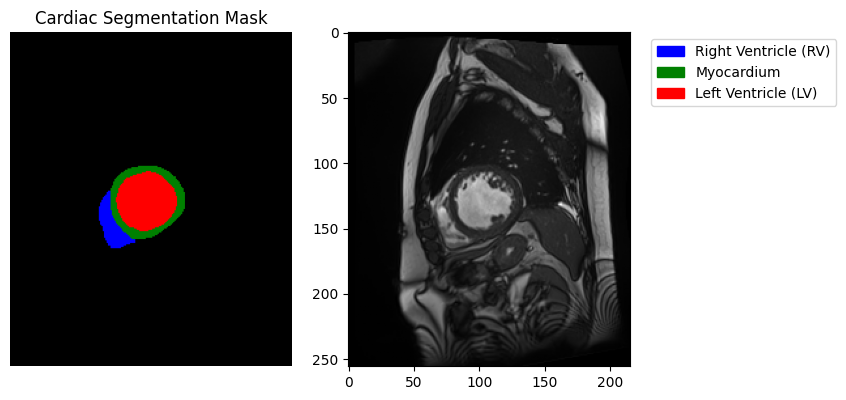

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

mask_path = "../data/patient001/patient001_frame01_gt.nii.gz"

ruta_imagen = '../data/patient001/patient001_frame01.nii.gz'

colors = [
    "black",      # background
    "blue",       # RV
    "green",      # myocardium
    "red"         # LV
]

cmap = ListedColormap(colors)

# 2. Cargar el objeto NIfTI y extraer la matriz matemática (píxeles)
image_data = nib.load(ruta_imagen).get_fdata()
mask = nib.load(mask_path).get_fdata()


#procesamiento de orientación
image_data = np.rot90(image_data, k=-1, axes=(0, 1))
image_data = np.fliplr(image_data)

mask = np.rot90(mask, k=-1, axes=(0, 1))
mask = np.fliplr(mask)

colors = [
    "black",      # background
    "blue",       # RV
    "green",      # myocardium
    "red"         # LV
]

cmap = ListedColormap(colors)

slice_idx = 5

fig, ax = plt.subplots(1,2,figsize=(8,8))

mask_slice = mask[:, :, slice_idx]

im = ax[0].imshow(mask_slice, cmap=cmap)

ax[0].set_title("Cardiac Segmentation Mask")
ax[0].axis("off")


image = image_data[:,:,slice_idx]  
im2 = ax[1].imshow(image, cmap = 'gray')


legend_labels = {
    1: "Right Ventricle (RV)",
    2: "Myocardium",
    3: "Left Ventricle (LV)"
}

patches = [
    mpatches.Patch(color=colors[label], label=name)
    for label, name in legend_labels.items()
]

plt.legend(
    handles=patches,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()



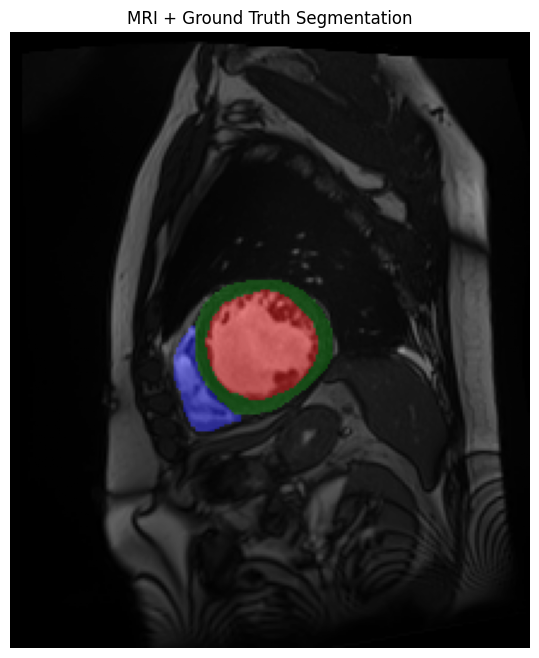

In [5]:
fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(image_data[:, :, slice_idx], cmap='gray')

ax.imshow(
    mask[:, :, slice_idx],
    cmap=cmap,
    alpha=0.4
)

ax.set_title("MRI + Ground Truth Segmentation")
ax.axis("off")

plt.show()